In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


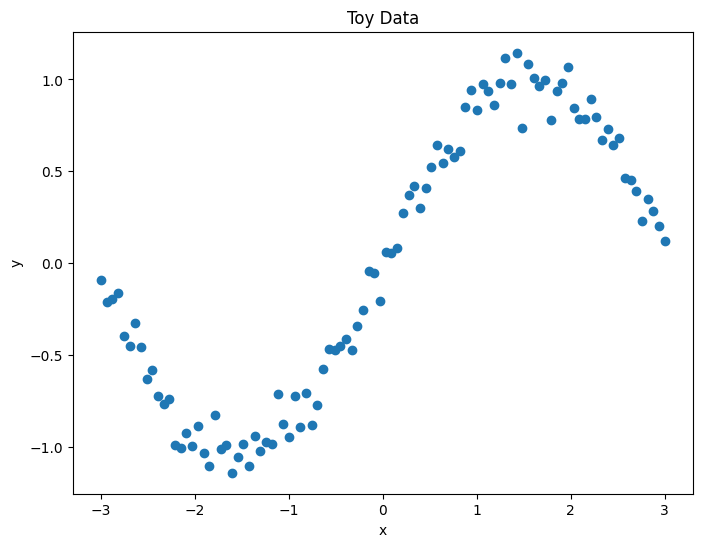

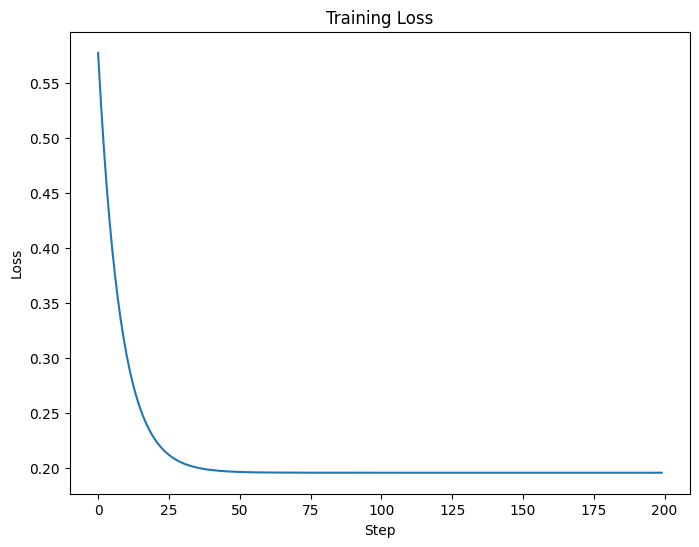

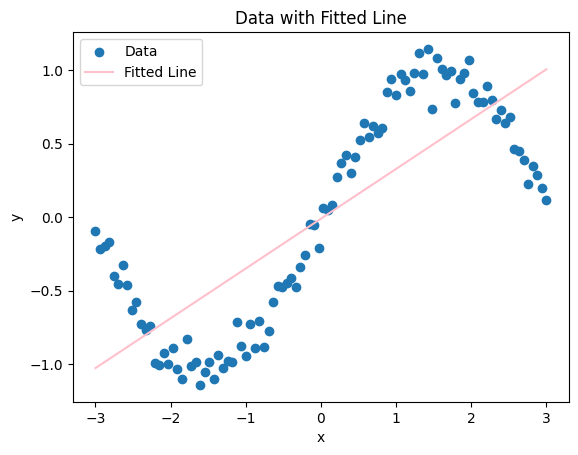

In [ ]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100); y = np.sin(x) + np.random.randn(100) * 0.1

#   Plot it.
plt.figure(figsize=(8, 6))
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Data')
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
losses = []
lr = 0.01
for step in range(200):
    y_hat = w * x + b

    loss  = np.mean((y_hat - y) ** 2)               # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db
    #   Record the loss at every step.
    losses.append(loss)
# TODO: Plot (a) the loss curve over the 200 steps, and
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
#           (b) the data with the fitted line on top.
plt.figure()
plt.scatter(x, y, label='Data')
plt.plot(x, w * x + b, color='pink', label='Fitted Line')
plt.title('Data with Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

**Student Reasoning — The single neuron 1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?**

![Derivative](image.jpeg)

**2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?**

The loss stops improving even though the predictions remain poor because a single neuron can only produce a linear (straight-line) function. The data, however, come from y = sin(x) + noise, which is fundamentally nonlinear. Gradient descent can only tune the two parameters w and b; it cannot alter the model’s functional form from a line into a curve. After enough iterations it simply converges to the best possible straight-line fit, and the loss plateaus. Capturing the true relationship therefore requires a model that can represent nonlinear mappings—for example a neural network with one or more hidden layers and nonlinear activation functions. The observed failure is classic underfitting: the model is too simple to express the pattern present in the data.